# Experiment 3: sampling and accumulation outcomes

Compare one sampled batch per table visit, a reshuffled disjoint full pass with one optimizer step per chunk, and the same full pass with one averaged-gradient optimizer step. There are 96 trials. The PD policy here is proportional within all three arms; it is not exchangeable with balanced-PD sampling in experiment 1.

## 0. Evidence and scope

The availability tables distinguish observed measurements from unavailable outcomes. Missing measurements are not zero effects.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from src.visualize import style, campaign as cp, publication as pub, diagnostics as dg
from src.visualize.figures import FigureSaver
from src.visualize.inputs import source_description
from src.data.dataset_names import display_frame
style.apply()
sink = FigureSaver('experiment3/02_results')
report = cp.NotebookReport('Experiment 3: sampling and accumulation outcomes', sink=sink)

print(source_description())
report.add('0. Evidence and scope', source_description())


DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.


## 1. Protocol coverage

The same reference recipe, bases and dataset partitions are used within this experiment; only the traversal/update protocol varies.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


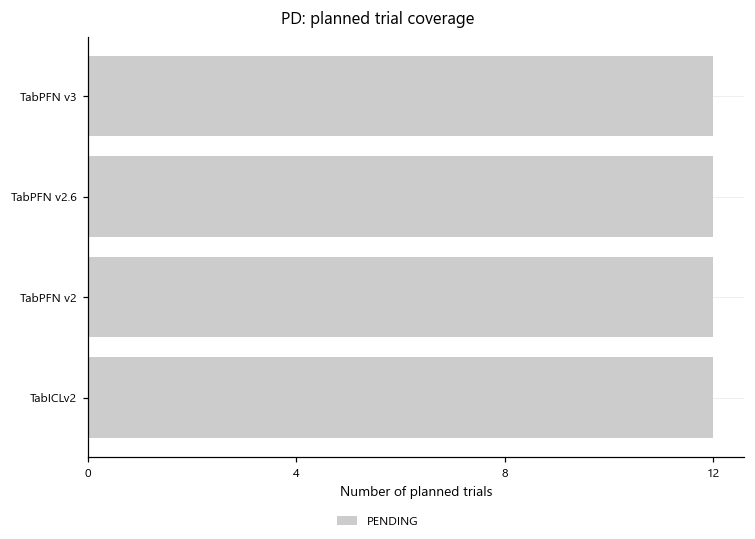

PD. Recorded status of 48 planned PD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

,evidence,records,origin
0,Planned trials,48,Config; not scheduler state
1,Completed trials,0,DATA manifests
2,Epoch rows,0,Project training diagnostics
3,Milestone rows,0,Project trajectory diagnostics
4,Benchmark folds,0,Project final evaluation


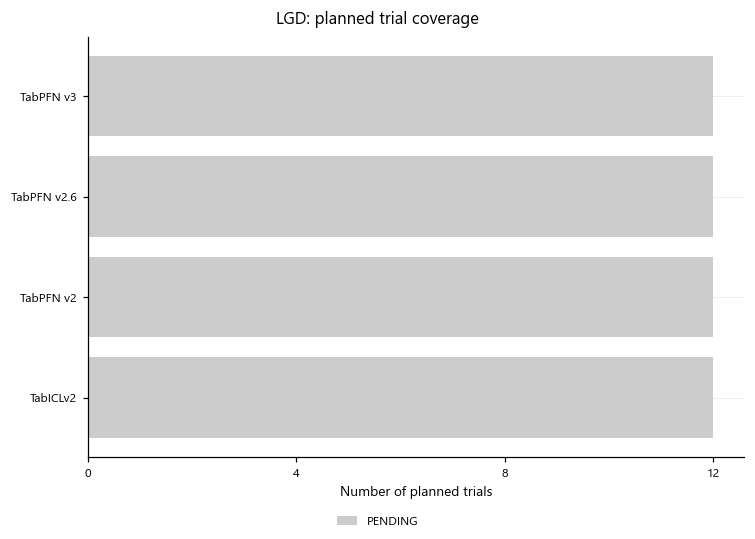

LGD. Recorded status of 48 planned LGD trials by base model. PENDING denotes no manifest outcome and can include currently running or queued jobs. INTERRUPTED denotes saved progress, not a numerical failure. This figure does not query the scheduler.

In [2]:
runs = [cp.load_campaign(3, track) for track in ('pd','lgd')]
for run in runs:
    report.table(run.track.upper()+' evidence', pub.availability(run))
    cp.show(sink, cp.plot_coverage(run), track=run.track)
report.add('1. Protocol coverage', '\n\n'.join(cp.coverage_summary(run) for run in runs))


## 2. Dataset-level protocol effects

Show every dataset and isolate protocol differences using matched observations.

In [3]:
for run in runs:
    cp.show(sink, pub.plot_sampling_endpoint(run), track=run.track)
    endpoint = cp.endpoint_effects(run)
    for mode in ('full_pass','accumulate'):
        cp.show(sink, cp.plot_contrasts(cp.factor_contrasts(endpoint, 'sampling', 'one_sample', mode), run.metric, mode+' minus one sample'), track=run.track)
report.add('2. Dataset-level protocol effects', 'Both contrasts hold the proportional-PD policy fixed within experiment 3.')


No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.


## 3. Cost and endpoint retention

Interpret endpoint differences alongside update cost and non-credit effects.

In [4]:
for run in runs:
    cp.show(sink, cp.plot_sampling_cost(run), track=run.track)
    cp.show(sink, pub.plot_retention_tradeoff(run), track=run.track)
report.add('3. Cost and endpoint retention', 'Equal update budgets need not mean equal compute or row exposure.')

No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.


## 4. Final evaluation

Final benchmark effects require complete paired outer folds and retain the same within-experiment protocol comparison.

In [5]:
for run in runs:
    cp.show(sink, cp.plot_eval_coverage(run), track=run.track)
    cp.show(sink, pub.plot_sampling_endpoint(run, benchmark=True), track=run.track)
report.add('4. Final evaluation', 'Do not attribute an experiment-1 versus experiment-3 difference solely to accumulation when their PD sampling policies also differ.')


No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.
No measurements available for this section yet.


## Complete text summary

Complete numerical values and figure captions, following the section order above.

In [6]:
print(report.summary(sink))

Experiment 3: sampling and accumulation outcomes

0. Evidence and scope
DATA: no external source selected.
Project: no external source selected.
Missing project records are unavailable evidence, not zero effects or failed training.

1. Protocol coverage
Run cpt_sampling_v5; PD; 48 planned trials; target 10,000 successful updates.
status
PENDING    48
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Run cpt_sampling_v5; LGD; 48 planned trials; target 10,000 successful updates.
status
PENDING    48
0 trajectory records; 0 benchmark fold records.
PENDING means no recorded outcome; it can include running or queued work. This is not live scheduler state.

Table: PD evidence
           evidence  records                          origin
0    Planned trials       48     Config; not scheduler state
1  Completed trials        0                  DATA manifests
2        Epoch rows        0   